Toplam veri sayısı: 34627
Görüntü boyutu: 28x28
X_digits boyutu: (34627, 28, 28)


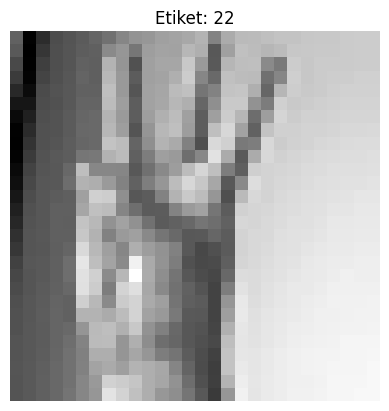

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Veri setlerini yükle
train_df = pd.read_csv('/content/sign_mnist_train.csv')
test_df = pd.read_csv('/content/sign_mnist_test.csv')

# Özellikleri ve etiketleri ayır
y_train_full = train_df['label'].values
X_train_full = train_df.drop('label', axis=1).values

y_test_full = test_df['label'].values
X_test_full = test_df.drop('label', axis=1).values

# Sign MNIST 28x28 boyutundadır
img_size = 28

# Tüm veriyi birleştirip notebook'taki X_digits, y_digits yapısına uyduralım (PCA, t-SNE vb. için)
X_flat = np.vstack((X_train_full, X_test_full))
y_digits = np.concatenate((y_train_full, y_test_full))

# 2D görüntü formatına çevir
X_digits = X_flat.reshape(-1, img_size, img_size)

# Orijinal eğitim/test bölünmesini koruyalım
X_train = X_train_full
X_test = X_test_full
y_train = y_train_full
y_test = y_test_full

print(f"Toplam veri sayısı: {X_flat.shape[0]}")
print(f"Görüntü boyutu: {img_size}x{img_size}")
print(f"X_digits boyutu: {X_digits.shape}")

# Örnek bir görüntüyü göster
plt.imshow(X_digits[7], cmap='gray')
plt.title(f"Etiket: {y_digits[7]}")
plt.axis('off')
plt.show()

In [ ]:
# ── Tüm kütüphaneleri içe aktar ───────────────────────────────────────────────
import numpy as np                          # Matris işlemleri — CNN'in kalbi
import matplotlib.pyplot as plt             # Görselleştirme
import matplotlib.colors as mcolors        # Renk haritası yardımcıları
from matplotlib.gridspec import GridSpec    # Karmaşık subplot düzeni

import cv2                                  # OpenCV — görüntü ön işleme
from scipy import datasets as scd           # Gerçek test görüntüleri

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA       # Temel Bileşen Analizi
from sklearn.manifold import TSNE           # t-dağılımlı Stokastik Komşu Yerleştirme
from sklearn.svm import SVC                 # Destek Vektör Makinesi
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier   # Çok Katmanlı Algılayıcı (sinir ağı)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
from sklearn.pipeline import Pipeline       # Ön işleme + model zinciri

import warnings
warnings.filterwarnings('ignore')

# ── Veri setlerini yükle ──────────────────────────────────────────────────────
# load_digits iptal edildi, önceki hücrede X_digits, y_digits vb. zaten tanımlandı.
img_color   = scd.face()                  # (768, 1024, 3) — gerçek fotoğraf
img_gray_raw = scd.ascent()              # (512, 512)     — gri fotoğraf

# Eğitim/test bölmesi — orijinal sign_mnist train/test dağılımını kullanıyoruz
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Eğitimde fit+transform
X_test_sc  = scaler.transform(X_test)        # Testte sadece transform

plt.rcParams['figure.dpi'] = 100
print("✅ Kurulum tamamlandı!")
print(f"   Eğitim: {X_train.shape[0]} örnek  |  Test: {X_test.shape[0]} örnek")
print(f"   Özellik boyutu: {X_flat.shape[1]} (28×28 piksel)")

✅ Kurulum tamamlandı!
   Eğitim: 27455 örnek  |  Test: 7172 örnek
   Özellik boyutu: 784 (28×28 piksel)


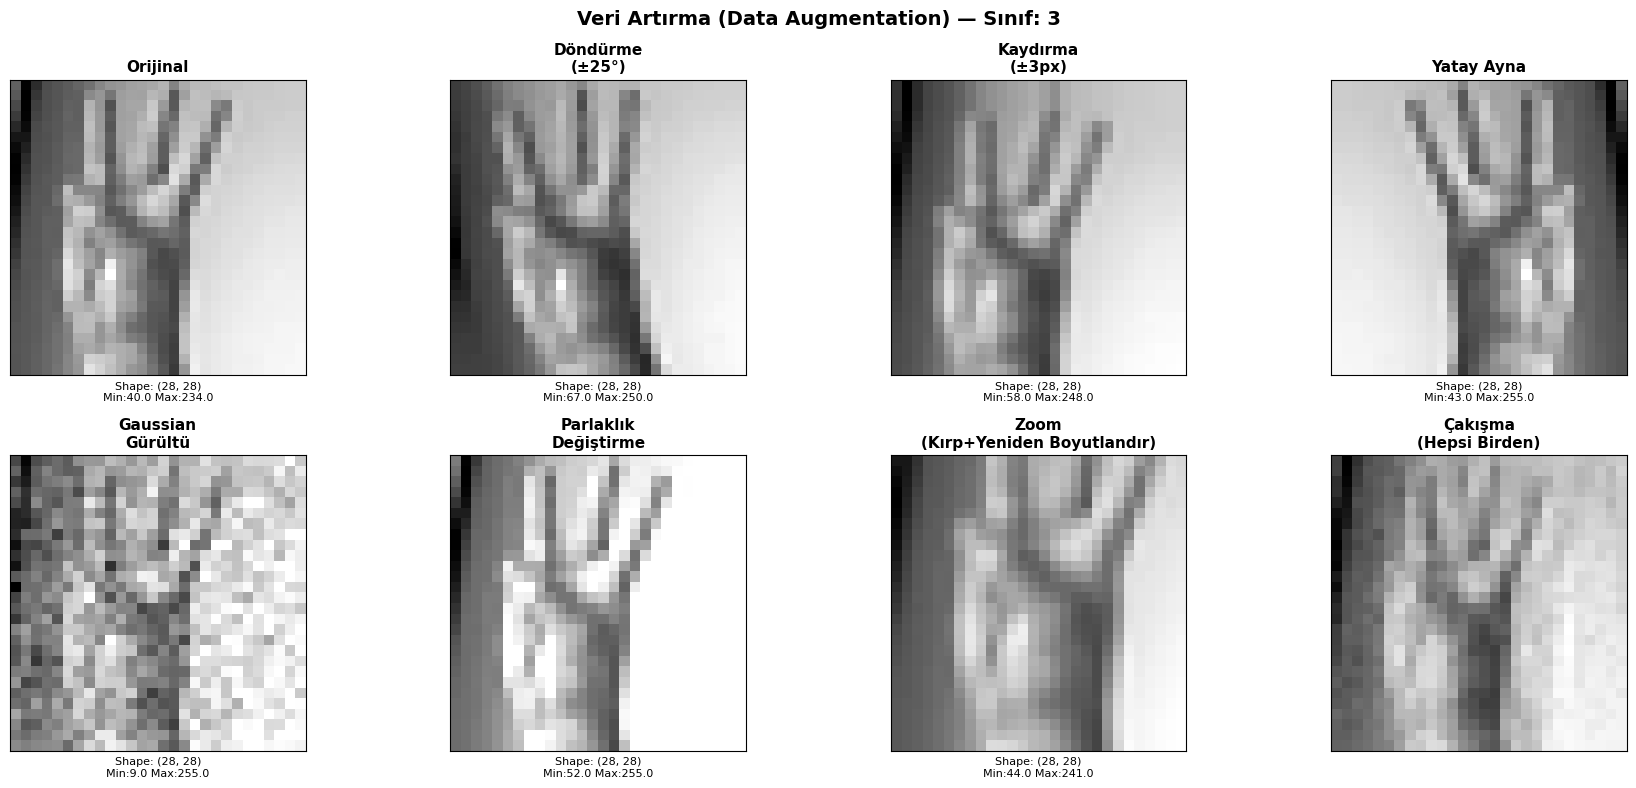

In [ ]:
def augment_image(img_2d, seed=None):
    # Tek bir 28x28 görüntüye rastgele augmentation uygula.
    rng = np.random.default_rng(seed)

    # Görüntüyü normalize et ve uint8 formatına çevir (0-255)
    img_uint8 = ((img_2d / img_2d.max()) * 255).astype(np.uint8)

    results = {}
    results['original'] = img_2d.copy()

    # ── 1. Döndürme (Rotation)
    angle = rng.uniform(-25, 25)
    h, w  = img_uint8.shape
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    rotated = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    results['rotation'] = rotated.astype(float)

    # ── 2. Kaydırma (Translation)
    tx = rng.uniform(-3.0, 3.0)  # 28x28 için kaydırma miktarını artırdık
    ty = rng.uniform(-3.0, 3.0)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    shifted = cv2.warpAffine(img_uint8, M_trans, (w, h), borderMode=cv2.BORDER_REPLICATE)
    results['translation'] = shifted.astype(float)

    # ── 3. Yatay Ayna (Horizontal Flip)
    flipped = np.fliplr(img_uint8)
    results['flip'] = flipped.astype(float)

    # ── 4. Gaussian Gürültü
    sigma  = rng.uniform(10, 30)
    noise  = rng.normal(0, sigma, img_uint8.shape).astype(np.int16)
    noisy  = np.clip(img_uint8.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    results['noise'] = noisy.astype(float)

    # ── 5. Parlaklık Değiştirme (Brightness)
    factor = rng.uniform(0.6, 1.6)
    bright = np.clip(img_uint8.astype(float) * factor, 0, 255).astype(np.uint8)
    results['brightness'] = bright.astype(float)

    # ── 6. Zoom (Kırp + Yeniden Boyutlandır)
    zoom   = rng.uniform(0.75, 0.95)
    crop_h = int(h * zoom)
    crop_w = int(w * zoom)
    y0     = rng.integers(0, h - crop_h + 1)
    x0     = rng.integers(0, w - crop_w + 1)
    cropped  = img_uint8[y0:y0+crop_h, x0:x0+crop_w]
    zoomed   = cv2.resize(cropped, (w, h))
    results['zoom'] = zoomed.astype(float)

    return results

sample_img = X_digits[7]
aug_results = augment_image(sample_img, seed=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

titles = ['Orijinal', 'Döndürme\n(±25°)', 'Kaydırma\n(±3px)',
          'Yatay Ayna', 'Gaussian\nGürültü', 'Parlaklık\nDeğiştirme',
          'Zoom\n(Kırp+Yeniden Boyutlandır)', 'Çakışma\n(Hepsi Birden)']

for i, (key, img) in enumerate(aug_results.items()):
    axes[i].imshow(img, cmap='gray', interpolation='nearest')
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f"Shape: {img.shape}\nMin:{img.min():.1f} Max:{img.max():.1f}", fontsize=8)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

combined = np.mean([v for v in aug_results.values()], axis=0)
axes[7].imshow(combined, cmap='gray', interpolation='nearest')
axes[7].set_title(titles[7], fontsize=11, fontweight='bold')
axes[7].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle(f"Veri Artırma (Data Augmentation) — Sınıf: {y_digits[0]}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def build_augmented_dataset(X_img, y, n_aug=2, seed=0):
    X_list, y_list = [X_img.flatten().reshape(len(X_img), -1)], [y]
    rng = np.random.default_rng(seed)

    for aug_round in range(n_aug):
        X_new = []
        for i, img in enumerate(X_img):
            s = rng.integers(0, 10000)
            aug = augment_image(img, seed=int(s))
            key = list(aug.keys())[1 + (aug_round % 6)]
            X_new.append(aug[key].flatten())  # 28x28 -> 784 özellik
        X_list.append(np.array(X_new))
        y_list.append(y)

    return np.vstack(X_list), np.concatenate(y_list)

print("Eğitim çok uzun sürmemesi için 2000 örnek seçiliyor...")
sample_size = 2000
idx_tr = np.random.choice(len(y_train), sample_size, replace=False)
idx_te = np.random.choice(len(y_test), 500, replace=False)

X_tr_imgs = X_train[idx_tr].reshape(-1, 28, 28)
y_tr      = y_train[idx_tr]
X_te_flat = X_test[idx_te]
y_te      = y_test[idx_te]

# Augmented dataset oluştur (Hız için n_aug=2)
X_aug, y_aug = build_augmented_dataset(X_tr_imgs, y_tr, n_aug=2)
print(f"Orijinal alt küme     : {len(y_tr)} örnek")
print(f"Augmented eğitim seti : {len(y_aug)} örnek  (3× büyüdü)")

sc = StandardScaler()
X_tr_sc  = sc.fit_transform(X_tr_imgs.reshape(sample_size, -1))
X_aug_sc = sc.fit_transform(X_aug)
X_te_sc  = sc.transform(X_te_flat)

mlp_orig = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=42)
mlp_aug  = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=42)

mlp_orig.fit(X_tr_sc,  y_tr)
mlp_aug.fit(X_aug_sc, y_aug)

acc_orig = accuracy_score(y_te, mlp_orig.predict(X_te_sc))
acc_aug  = accuracy_score(y_te, mlp_aug.predict(X_te_sc))

print(f"\nTest Doğruluğu — Orijinal veri : {acc_orig*100:.2f}%")
print(f"Test Doğruluğu — Augmented veri: {acc_aug*100:.2f}%")
print(f"Augmentation kazancı            : {(acc_aug-acc_orig)*100:+.2f} puan")

Eğitim çok uzun sürmemesi için 2000 örnek seçiliyor...
Orijinal alt küme     : 2000 örnek
Augmented eğitim seti : 6000 örnek  (3× büyüdü)

Test Doğruluğu — Orijinal veri : 77.40%
Test Doğruluğu — Augmented veri: 81.40%
Augmentation kazancı            : +4.00 puan


%90 varyans için gerekli bileşen: 59
%95 varyans için gerekli bileşen: 115
Orijinal boyut: 784  →  Sıkıştırma oranı (%90): 13.3×


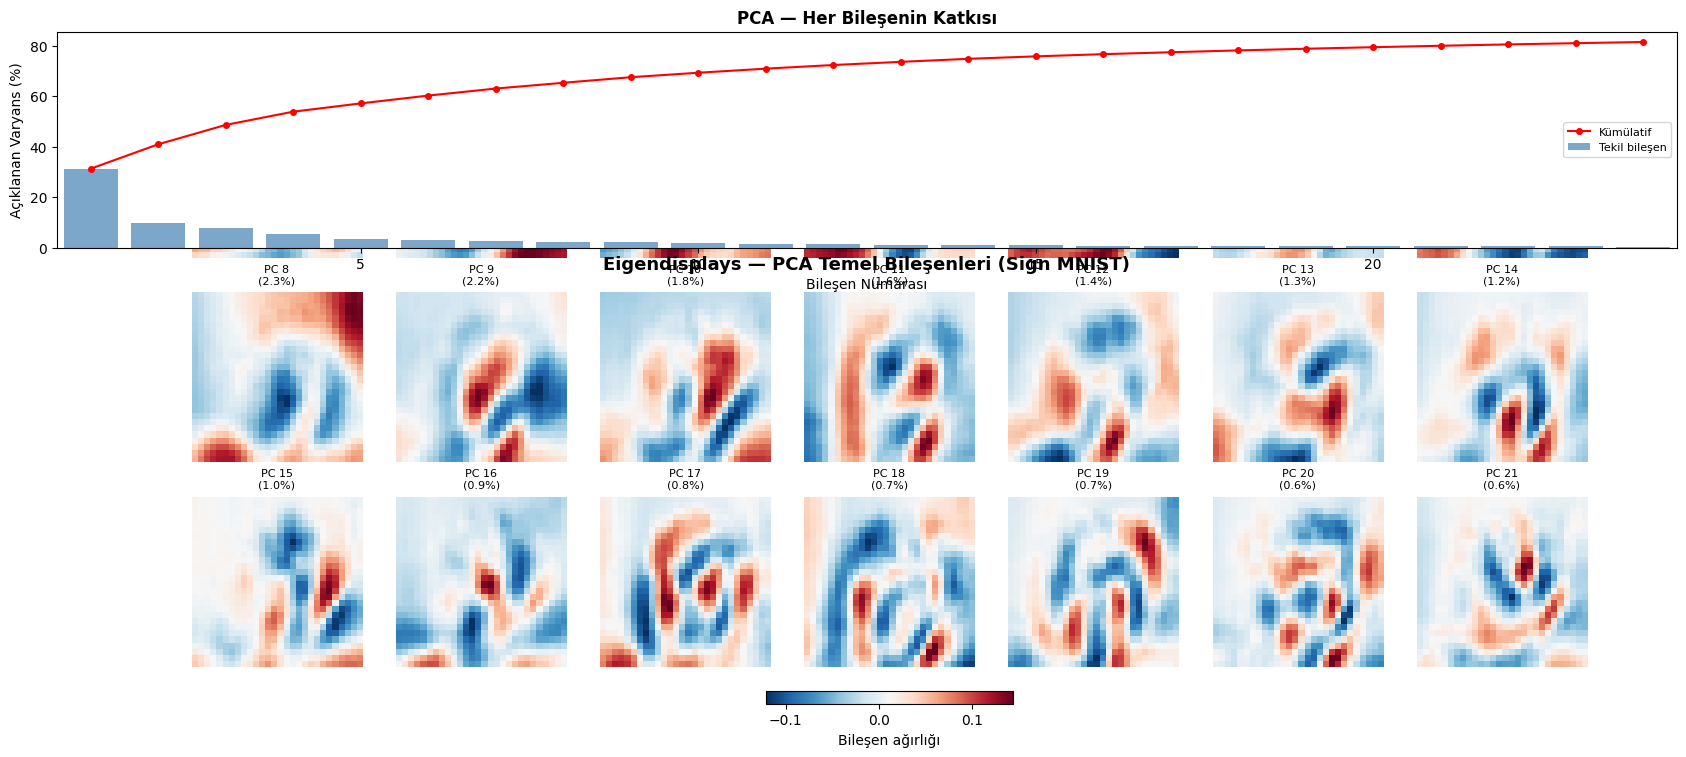

In [ ]:
# ── PCA ile Boyut İndirgeme ───────────────────────────────────────────────────
# 784 bileşenin hepsini değil, büyük veri setinde belleği korumak için max 150 hesaplayalım
pca_full = PCA(n_components=150)
pca_full.fit(X_flat)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90  = np.searchsorted(cumvar, 0.90) + 1
n95  = np.searchsorted(cumvar, 0.95) + 1

print(f"%90 varyans için gerekli bileşen: {n90}")
print(f"%95 varyans için gerekli bileşen: {n95}")
print(f"Orijinal boyut: 784  →  Sıkıştırma oranı (%90): {784/n90:.1f}×")

fig, axes = plt.subplots(3, 7, figsize=(18, 8))

ax_var = fig.add_axes([0.05, 0.68, 0.90, 0.27])
ax_var.bar(range(1, 25), pca_full.explained_variance_ratio_[:24]*100,
           color='steelblue', alpha=0.7, label='Tekil bileşen')
ax_var.plot(range(1, 25), cumvar[:24]*100,
            'ro-', markersize=4, linewidth=1.5, label='Kümülatif')
ax_var.set_xlabel("Bileşen Numarası")
ax_var.set_ylabel("Açıklanan Varyans (%)")
ax_var.set_title("PCA — Her Bileşenin Katkısı", fontweight='bold')
ax_var.legend(loc='right', fontsize=8)
ax_var.set_xlim(0.5, 24.5)

for i, ax in enumerate(axes.flatten()):
    if i < 21:
        eigenimg = pca_full.components_[i].reshape(28, 28)   # 784 → 28×28
        im = ax.imshow(eigenimg, cmap='RdBu_r')
        ax.set_title(f"PC {i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}%)", fontsize=8)
        ax.axis('off')

fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.04, label='Bileşen ağırlığı')
plt.suptitle("Eigendisplays — PCA Temel Bileşenleri (Sign MNIST)", fontsize=13, fontweight='bold', y=0.67)
plt.show()

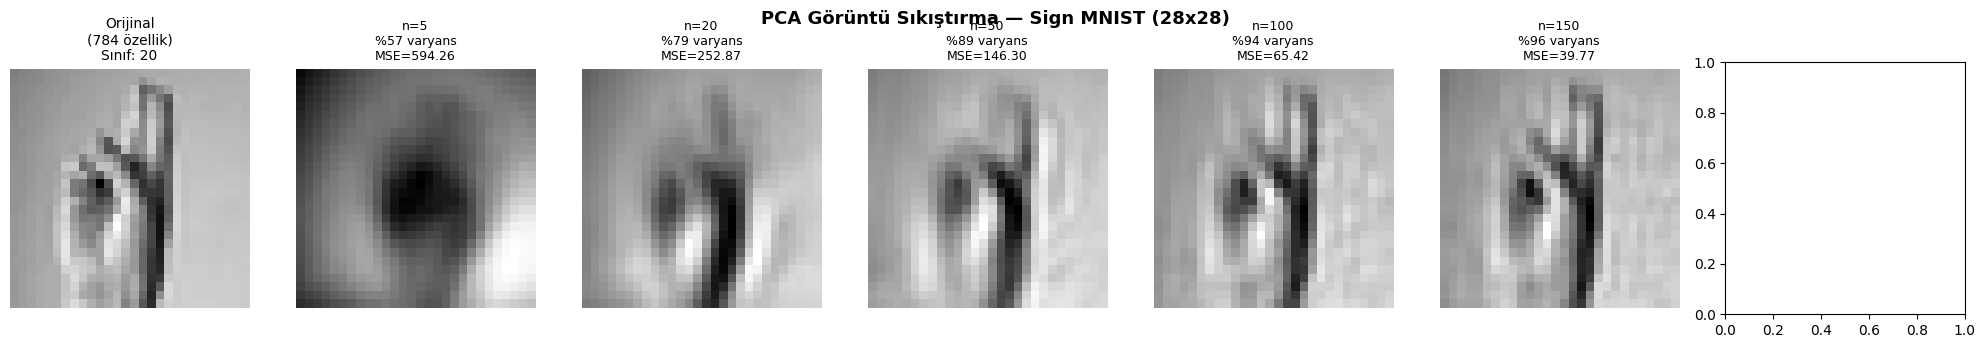

In [ ]:
# ── PCA ile Görüntü Sıkıştırma ve Yeniden Yapılandırma ───────────────────────
n_components_list = [5, 20, 50, 100, 150]
sample_idx = 42
original   = X_flat[sample_idx]

fig, axes = plt.subplots(1, len(n_components_list)+2, figsize=(20, 3.5))

axes[0].imshow(original.reshape(28,28), cmap='gray', interpolation='nearest')
axes[0].set_title(f"Orijinal\n(784 özellik)\nSınıf: {y_digits[sample_idx]}", fontsize=10)
axes[0].axis('off')

for j, n in enumerate(n_components_list):
    pca_n = PCA(n_components=n)
    pca_n.fit(X_flat)

    compressed = pca_n.transform(X_flat[sample_idx:sample_idx+1])
    reconstructed = pca_n.inverse_transform(compressed)

    mse = np.mean((original - reconstructed[0])**2)
    var_exp = np.sum(pca_n.explained_variance_ratio_) * 100

    axes[j+1].imshow(reconstructed[0].reshape(28,28), cmap='gray', interpolation='nearest')
    axes[j+1].set_title(f"n={n}\n%{var_exp:.0f} varyans\nMSE={mse:.2f}", fontsize=9)
    axes[j+1].axis('off')

plt.suptitle("PCA Görüntü Sıkıştırma — Sign MNIST (28x28)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Adım 1: PCA ile 50 boyuta indir (Daha fazla bilgi koruyoruz)...
Adım 2: t-SNE ile 2 boyuta indir (İyileştirilmiş parametreler)...


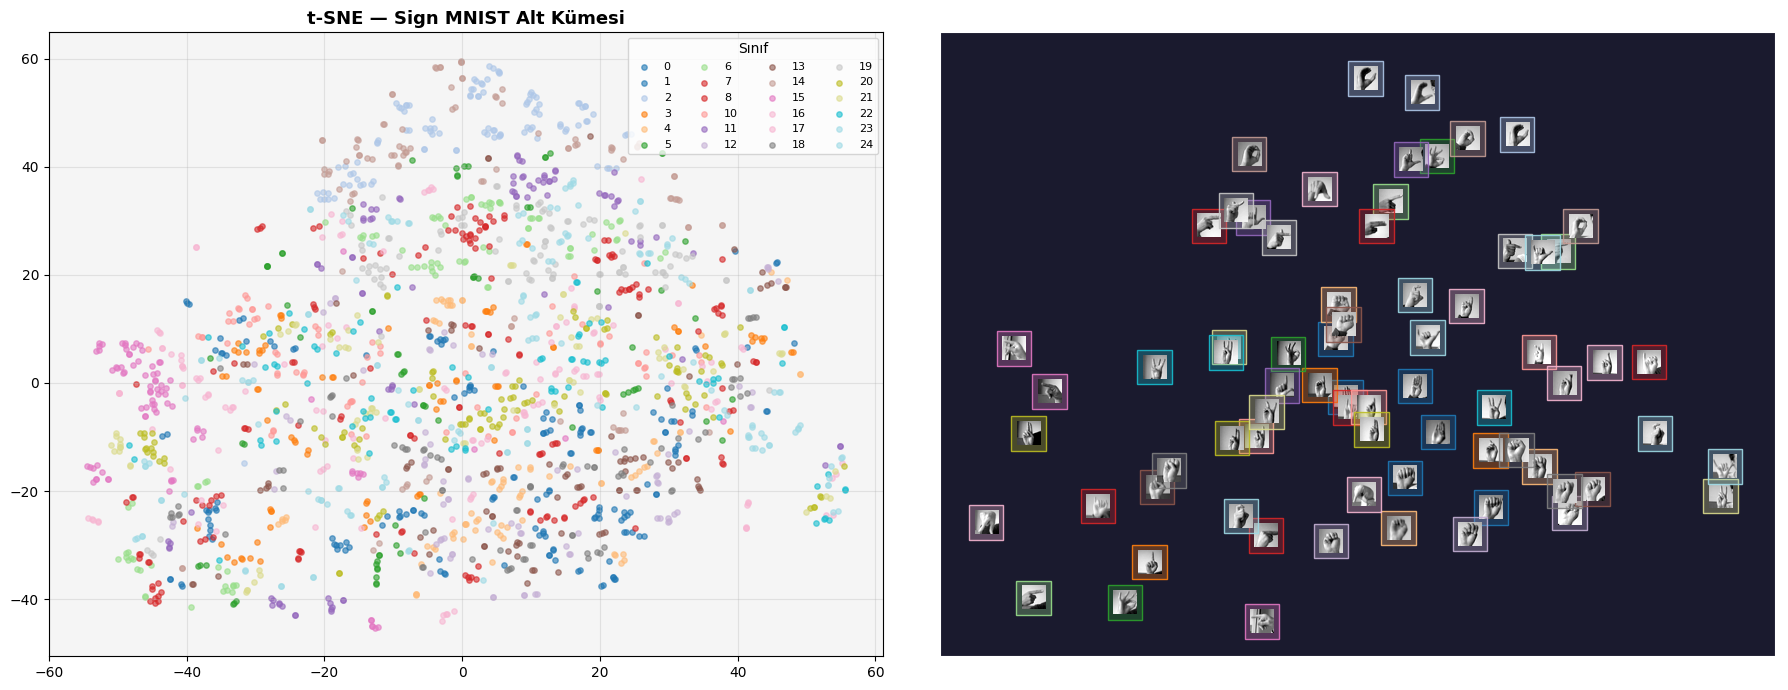

In [ ]:
# t-SNE büyük veride yavaş olduğu için 2000 örnekten oluşan bir alt küme alıyoruz
subset_size = 2000
idx_tsne = np.random.choice(len(X_flat), subset_size, replace=False)
X_sub = X_flat[idx_tsne]
y_sub = y_digits[idx_tsne]
X_digits_sub = X_digits[idx_tsne]

print("Adım 1: PCA ile 50 boyuta indir (Daha fazla bilgi koruyoruz)...")
pca_pre = PCA(n_components=50, random_state=42)
X_pca_sub = pca_pre.fit_transform(X_sub)

print("Adım 2: t-SNE ile 2 boyuta indir (İyileştirilmiş parametreler)...")
# perplexity artırıldı, max_iter artırıldı
tsne = TSNE(n_components=2, perplexity=45, max_iter=1500, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca_sub)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sign MNIST 24 farklı sınıfa sahiptir, renk haritasını büyütelim
unique_classes = np.unique(y_sub)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_classes)))

# Sol: t-SNE scatter plot
for i, cls in enumerate(unique_classes):
    mask = y_sub == cls
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[colors[i]], label=str(cls), alpha=0.6, s=15)

axes[0].set_title("t-SNE — Sign MNIST Alt Kümesi", fontsize=13, fontweight='bold')
axes[0].legend(title="Sınıf", ncol=4, fontsize=8, loc='upper right')
axes[0].set_facecolor('#f5f5f5')
axes[0].grid(True, alpha=0.3)

# Sağ: t-SNE üzerine gerçek görüntüler
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title("t-SNE — Örnek Görüntülerle", fontsize=13, fontweight='bold', color='white')

from matplotlib.offsetbox import AnnotationBbox, OffsetImage
rng = np.random.default_rng(0)
for i, cls in enumerate(unique_classes):
    mask_idx = np.where(y_sub == cls)[0]
    sample_indices = rng.choice(mask_idx, size=min(3, len(mask_idx)), replace=False)

    for idx in sample_indices:
        img = X_digits_sub[idx] # 28x28
        x, y_pos = X_tsne[idx, 0], X_tsne[idx, 1]
        colored = colors[i][:3]
        imagebox = OffsetImage(img, zoom=0.6, cmap='gray')
        ab = AnnotationBbox(imagebox, (x, y_pos), frameon=True, bboxprops=dict(facecolor=(*colored, 0.3), edgecolor=(*colored, 0.9), linewidth=1.0))
        axes[1].add_artist(ab)

axes[1].set_xlim(X_tsne[:,0].min()-5, X_tsne[:,0].max()+5)
axes[1].set_ylim(X_tsne[:,1].min()-5, X_tsne[:,1].max()+5)
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('white')

plt.tight_layout()
plt.show()

Farklı perplexity değerleri ile t-SNE hesaplanıyor. Bu işlem biraz sürebilir...
Perplexity = 10 hesaplanıyor...
Perplexity = 30 hesaplanıyor...
Perplexity = 50 hesaplanıyor...


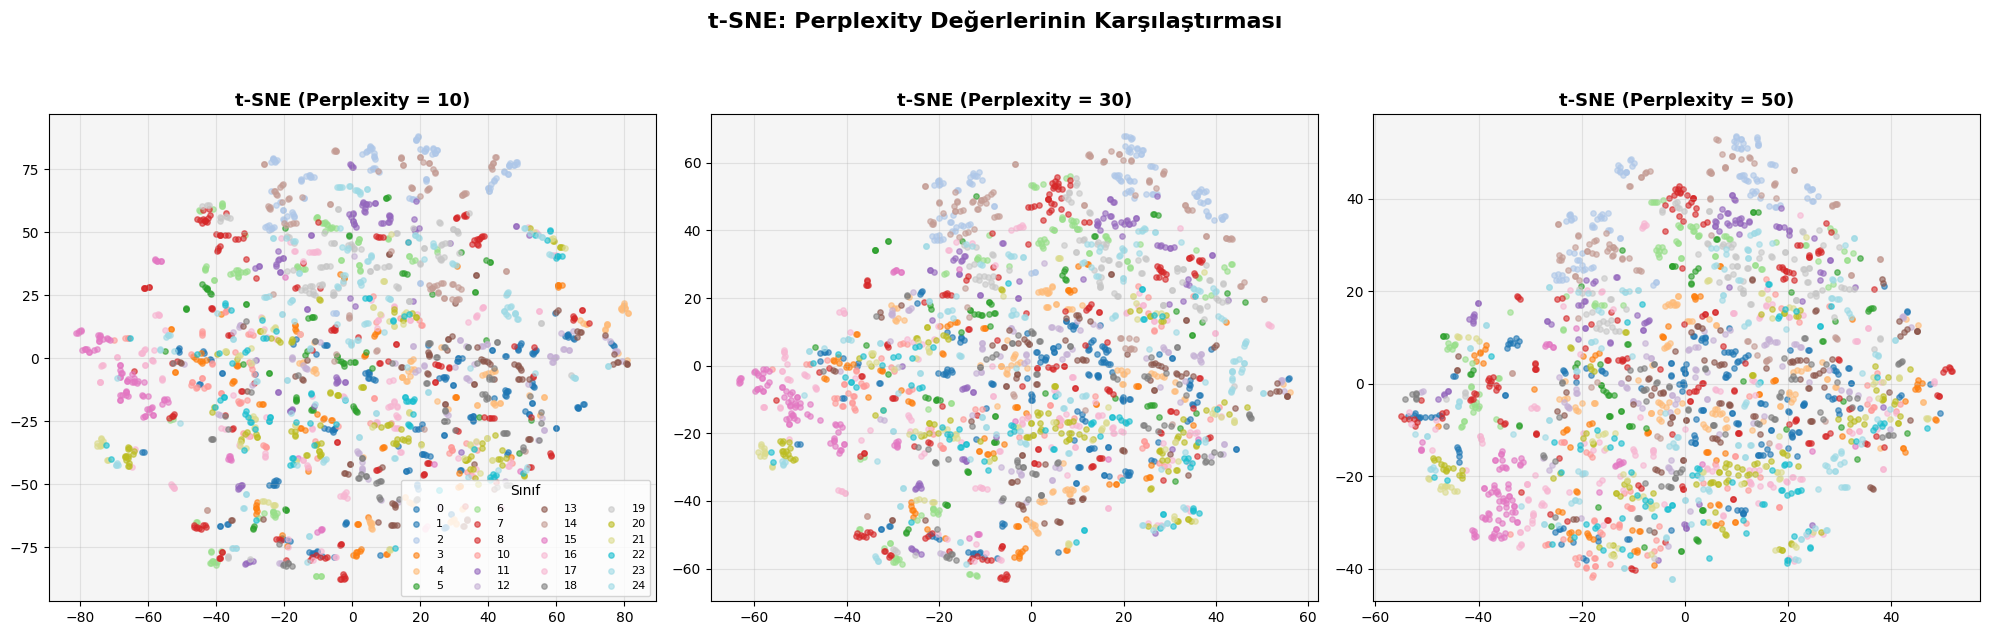

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

perplexities = [10, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

print("Farklı perplexity değerleri ile t-SNE hesaplanıyor. Bu işlem biraz sürebilir...")

for i, p in enumerate(perplexities):
    print(f"Perplexity = {p} hesaplanıyor...")
    # t-SNE modelini ilgili perplexity değeri ile oluştur
    tsne_model = TSNE(n_components=2, perplexity=p, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
    X_tsne_p = tsne_model.fit_transform(X_pca_sub) # Daha önce elde ettiğimiz PCA verisini kullanıyoruz

    # Alt kümeyi (scatter plot) çizdir
    for j, cls in enumerate(unique_classes):
        mask = y_sub == cls
        axes[i].scatter(X_tsne_p[mask, 0], X_tsne_p[mask, 1], c=[colors[j]], label=str(cls) if i==0 else "", alpha=0.6, s=15)

    axes[i].set_title(f"t-SNE (Perplexity = {p})", fontsize=13, fontweight='bold')
    axes[i].set_facecolor('#f5f5f5')
    axes[i].grid(True, alpha=0.3)

# Sadece ilk grafiğe etiketleri (legend) ekleyelim
axes[0].legend(title="Sınıf", ncol=4, fontsize=8, loc='best')

plt.suptitle("t-SNE: Perplexity Değerlerinin Karşılaştırması", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Örnek görüntülerle farklı perplexity değerleri için t-SNE hesaplanıyor...
Perplexity = 10 hesaplanıyor ve çiziliyor...
Perplexity = 30 hesaplanıyor ve çiziliyor...
Perplexity = 50 hesaplanıyor ve çiziliyor...


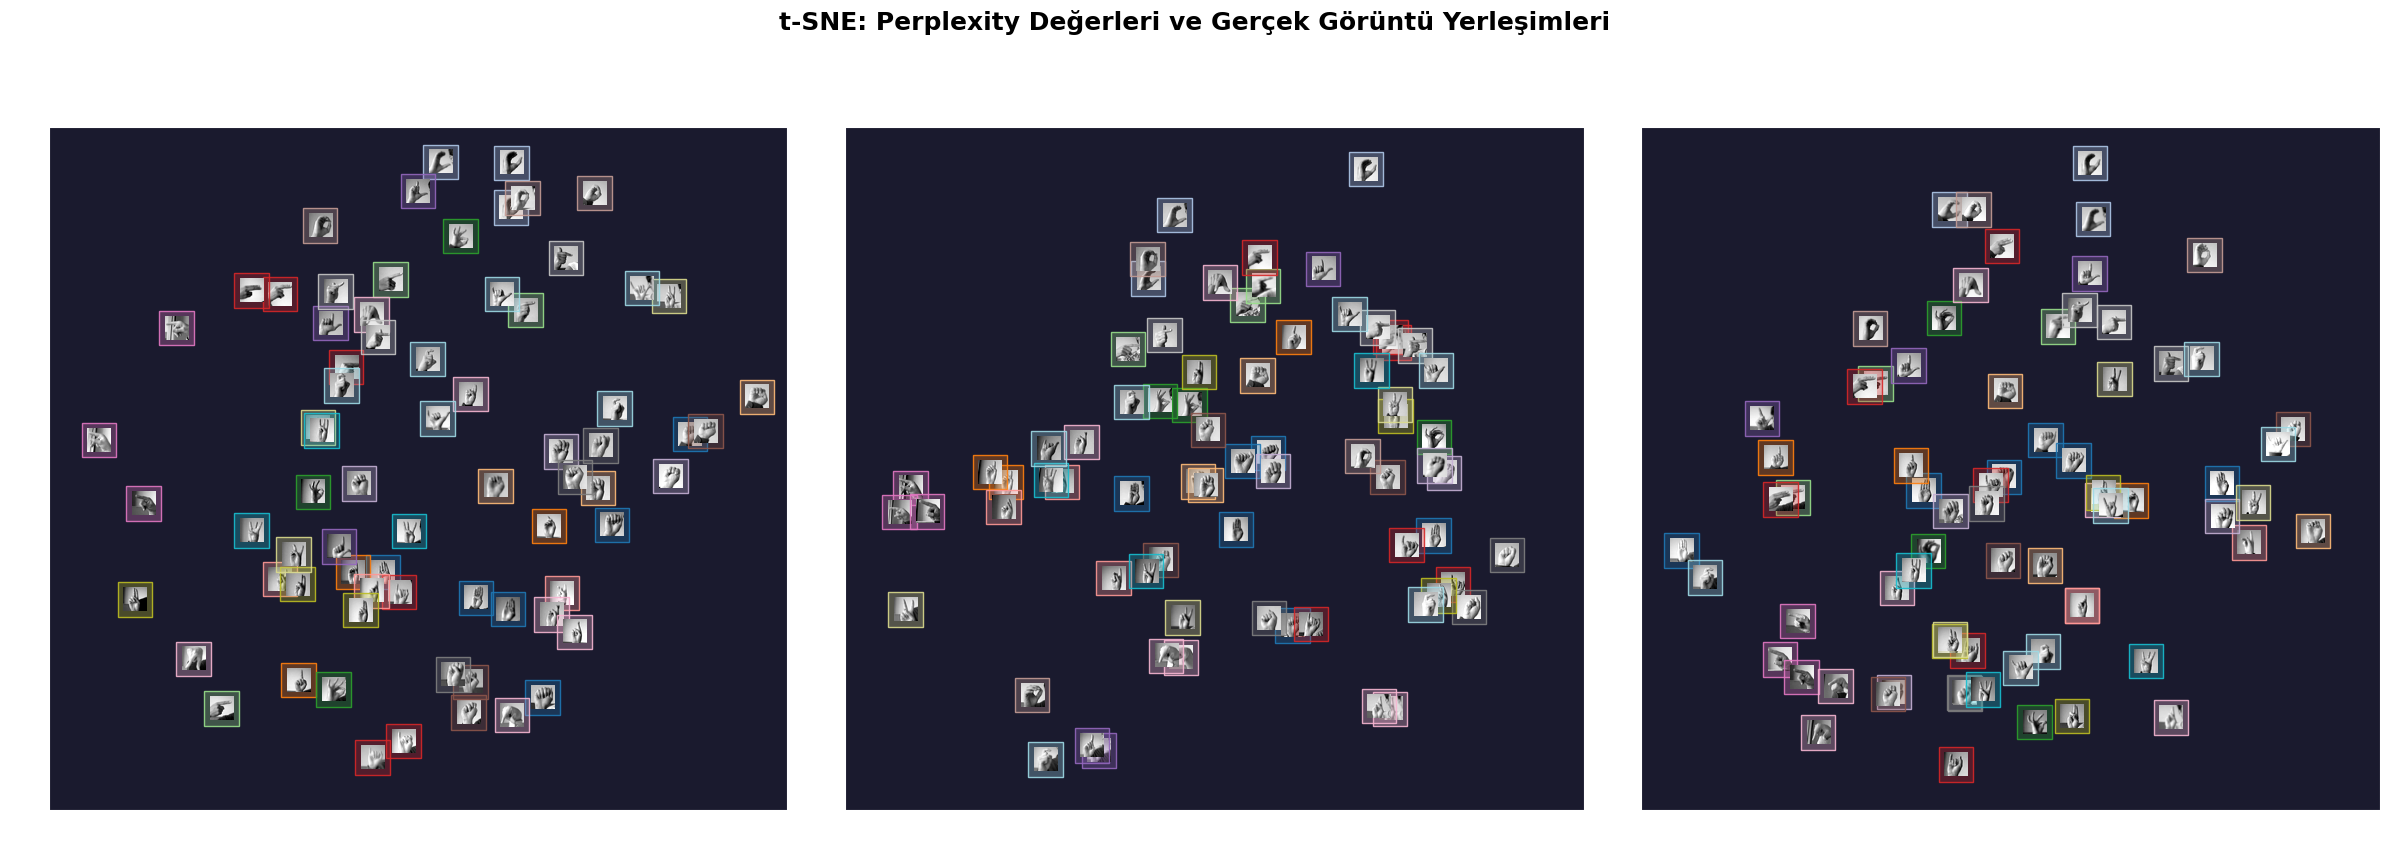

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from sklearn.manifold import TSNE

perplexities = [10, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Görüntüleri seçmek için rastgelelik üreteci
rng = np.random.default_rng(0)

print("Örnek görüntülerle farklı perplexity değerleri için t-SNE hesaplanıyor...")

for i, p in enumerate(perplexities):
    print(f"Perplexity = {p} hesaplanıyor ve çiziliyor...")
    # t-SNE modelini hesapla
    tsne_model = TSNE(n_components=2, perplexity=p, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
    X_tsne_p = tsne_model.fit_transform(X_pca_sub)

    # Arka plan ve başlık ayarları
    axes[i].set_facecolor('#1a1a2e')
    axes[i].set_title(f"t-SNE (Perplexity = {p})", fontsize=14, fontweight='bold', color='white')

    # Gerçek görüntüleri (OffsetImage) grafik üzerine yerleştir
    for j, cls in enumerate(unique_classes):
        mask_idx = np.where(y_sub == cls)[0]
        # Her sınıftan rastgele max 3 görüntü seçiyoruz ki grafik çok kalabalık olmasın
        sample_indices = rng.choice(mask_idx, size=min(3, len(mask_idx)), replace=False)

        for idx in sample_indices:
            img = X_digits_sub[idx] # 28x28 görüntü
            x, y_pos = X_tsne_p[idx, 0], X_tsne_p[idx, 1]
            colored = colors[j][:3] # Sınıfın rengi

            imagebox = OffsetImage(img, zoom=0.6, cmap='gray')
            ab = AnnotationBbox(imagebox, (x, y_pos), frameon=True,
                                bboxprops=dict(facecolor=(*colored, 0.3), edgecolor=(*colored, 0.9), linewidth=1.0))
            axes[i].add_artist(ab)

    # Eksen sınırlarını ayarla ki görüntüler dışarı taşmasın
    axes[i].set_xlim(X_tsne_p[:,0].min()-5, X_tsne_p[:,0].max()+5)
    axes[i].set_ylim(X_tsne_p[:,1].min()-5, X_tsne_p[:,1].max()+5)
    axes[i].tick_params(colors='white')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('white')

plt.suptitle("t-SNE: Perplexity Değerleri ve Gerçek Görüntü Yerleşimleri", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()